In [4]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 976.0 kB/s eta 0:00:10
   -- ------------------------------------- 0.5/9.5 MB 976.0 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/9.5 MB 1.0 MB/s eta 0:00:09
   ---- ----------------------------------- 1.0/9.5 MB 974.5 kB/s eta 0:00:09
   ----- ---------------------------------- 1.3/9.5 MB 989.8 kB/s eta 0:00:09
   ------ --------------------------------- 1.6/9.5 MB 1.0 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.5 MB 1.1 MB/s eta 0:00:08
   -------- ------------------------------- 2.1/9.5 MB 1.1 MB/s eta 0:00:07
   --------- ------------------------------ 2.4/9.5 MB 1.1 MB/s eta 0:00:07
   ---------- ----------------------------- 2.6/9.5 MB 1.1 MB/s eta 0:00:07
   ------------ ---------


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 

from sklearn.preprocessing import OneHotEncoder 
from sklearn.impute import SimpleImputer 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import GridSearchCV

from statsmodels.tsa.holtwinters import ExponentialSmoothing 

import warnings 
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('data.csv')
print(df.head())
print(df.shape)


   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [8]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None
              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000    

In [9]:
df.drop_duplicates(inplace=True)
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(),inplace = True)

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0],inplace= True)

In [12]:
print(df.columns.tolist())

['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


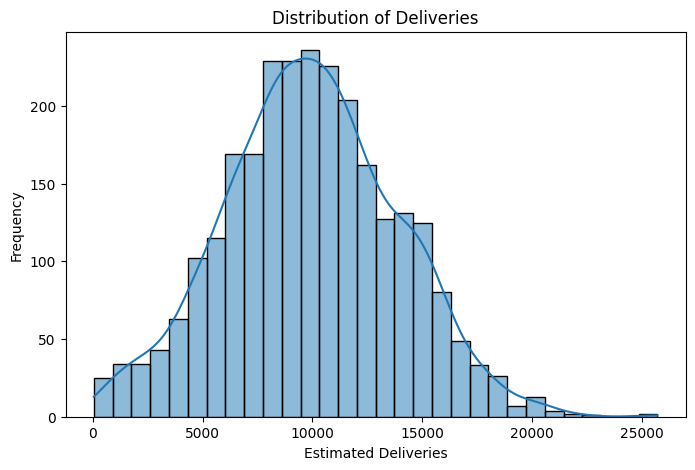

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Estimated_Deliveries'],
    bins=30,
    kde=True
)

plt.title("Distribution of Deliveries")
plt.xlabel("Estimated Deliveries")
plt.ylabel("Frequency")

plt.show()

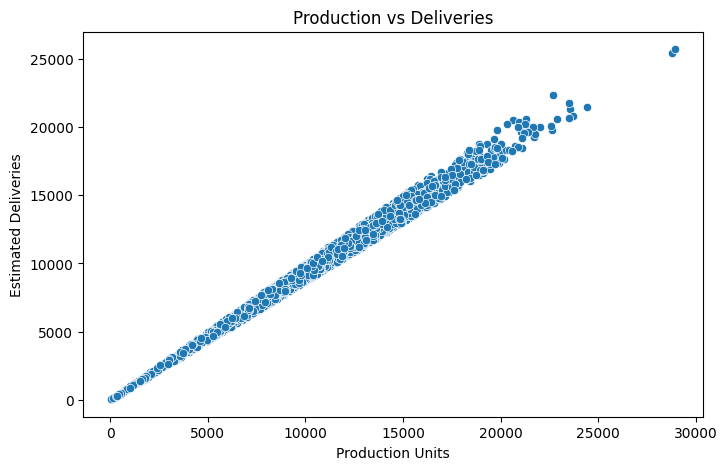

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Production_Units',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Production vs Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.show()

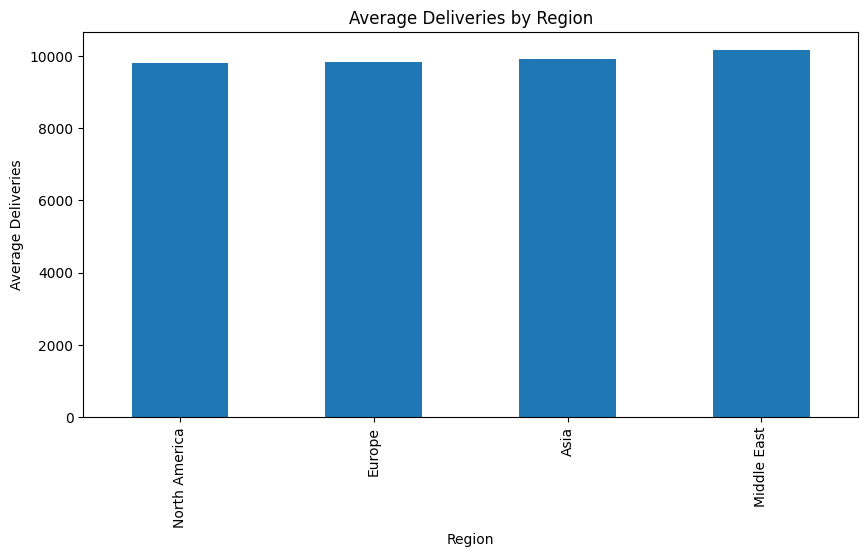

In [15]:
plt.figure(figsize=(10,5))

df.groupby('Region')['Estimated_Deliveries'] \
  .mean() \
  .sort_values() \
  .plot(kind='bar')

plt.title("Average Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Average Deliveries")

plt.show()

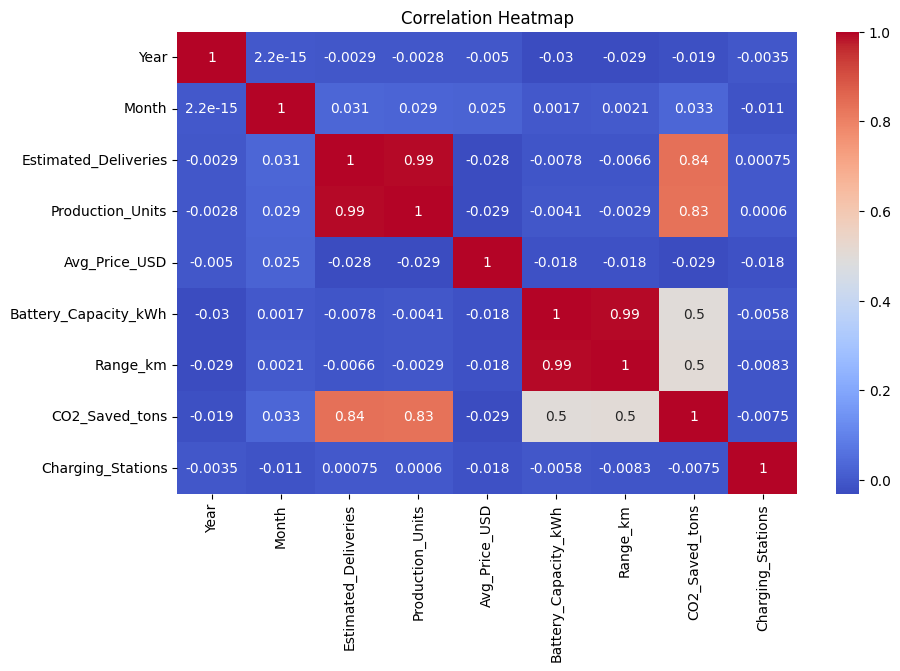

In [16]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [17]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str)
)

In [18]:
df['Production_Efficiency'] = (
    df['Estimated_Deliveries'] /
    df['Production_Units']
)

df['Price_per_km'] = (
    df['Avg_Price_USD'] /
    df['Range_km']
)

In [19]:
X = df.drop(
    columns=['Estimated_Deliveries', 'Date']
)

y = df['Estimated_Deliveries']

In [20]:
categorical_cols = X.select_dtypes(include='object').columns

numerical_cols = X.select_dtypes(exclude='object').columns

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_cols
        ),
        (
            'num',
            SimpleImputer(strategy='median'),
            numerical_cols
        )
    ]
)

In [22]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42
    ))
])

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Region', 'Model', 'Source_Type'], dtype='object')),
                                                 ('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Production_Efficiency', 'Price_per_km'],
      dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [25]:
preds = pipeline.predict(X_test)

In [26]:
mae = mean_absolute_error(y_test, preds)

rmse = np.sqrt(
    mean_squared_error(y_test, preds)
)

r2 = r2_score(y_test, preds)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 67.22339015151515
RMSE : 112.56603062287218
R2 Score : 0.9991499485897205


In [27]:
param_grid = {
    'model__n_estimators':[100,200],
    'model__max_depth':[10,20,None],
    'model__min_samples_split':[2,5]
}

In [28]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [29]:
best_model = grid.best_estimator_

preds = best_model.predict(X_test)

print(
    "Tuned R2:",
    r2_score(y_test,preds)
)

Tuned R2: 0.9991499485897205


In [30]:
rf = best_model.named_steps['model']

importances = rf.feature_importances_

feature_names = (
    best_model.named_steps['preprocessor']
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    'Feature':feature_names,
    'Importance':importances
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(15))

                                Feature  Importance
14                num__Production_Units    0.990327
20           num__Production_Efficiency    0.008635
18                  num__CO2_Saved_tons    0.000179
13                           num__Month    0.000134
21                    num__Price_per_km    0.000117
15                   num__Avg_Price_USD    0.000110
17                        num__Range_km    0.000104
19               num__Charging_Stations    0.000103
12                            num__Year    0.000075
11  cat__Source_Type_Official (Quarter)    0.000037
0                      cat__Region_Asia    0.000025
16            num__Battery_Capacity_kWh    0.000023
3             cat__Region_North America    0.000022
8                    cat__Model_Model Y    0.000016
2               cat__Region_Middle East    0.000015


In [34]:
monthly = df.groupby(
    ['Year','Month']
)['Estimated_Deliveries'].sum().reset_index()

In [35]:
monthly['Date'] = pd.to_datetime(
    monthly['Year'].astype(str)
    + '-' +
    monthly['Month'].astype(str)
)

monthly = monthly.sort_values('Date')

In [36]:
ts = monthly.set_index(
    'Date'
)['Estimated_Deliveries']

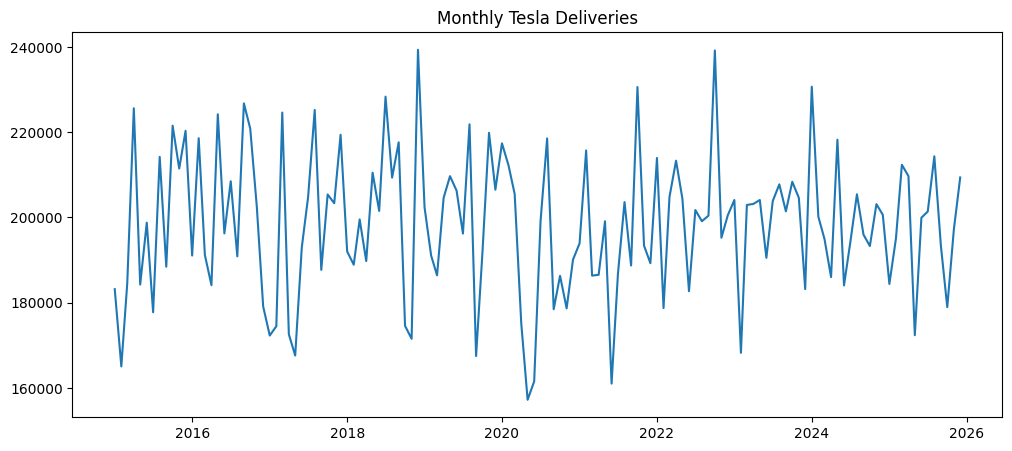

In [37]:
plt.figure(figsize=(12,5))
plt.plot(ts)
plt.title("Monthly Tesla Deliveries")
plt.show()

In [38]:
model = ExponentialSmoothing(
    ts,
    trend='add',
    seasonal=None
)

fit = model.fit()

In [39]:
forecast = fit.forecast(12)

print(forecast)

2026-01-01    199247.263710
2026-02-01    199352.326837
2026-03-01    199457.389964
2026-04-01    199562.453091
2026-05-01    199667.516218
2026-06-01    199772.579346
2026-07-01    199877.642473
2026-08-01    199982.705600
2026-09-01    200087.768727
2026-10-01    200192.831854
2026-11-01    200297.894981
2026-12-01    200402.958108
Freq: MS, dtype: float64


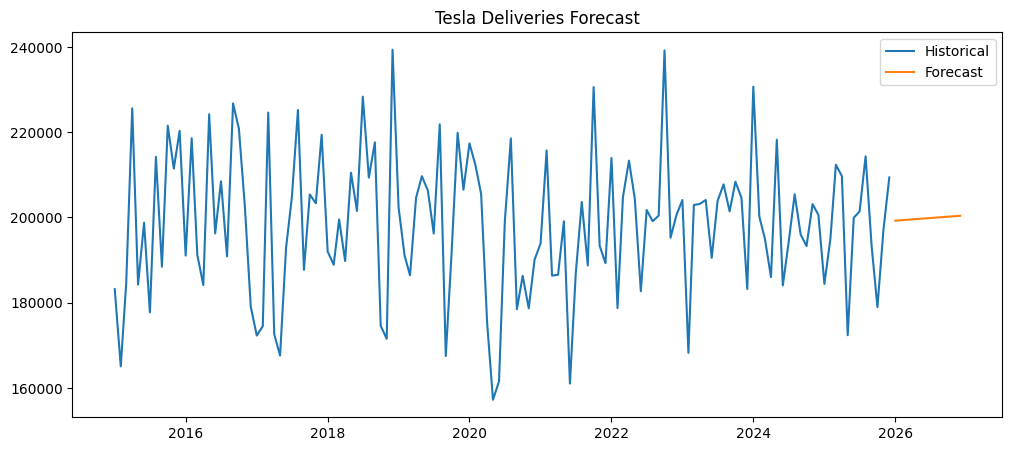

In [40]:
plt.figure(figsize=(12,5))

plt.plot(
    ts,
    label='Historical'
)

plt.plot(
    forecast,
    label='Forecast'
)

plt.legend()

plt.title(
    "Tesla Deliveries Forecast"
)

plt.show()

In [41]:
import joblib

joblib.dump(
    best_model,
    "tesla_delivery_model.pkl"
)

['tesla_delivery_model.pkl']